# Loading the data

In [1]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from pathlib import Path

In [2]:
dataset_path = Path('dataset/dataset/train')

In [3]:
classes = sorted([d.name for d in dataset_path.iterdir() if d.is_dir()])
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
print(class_to_idx)

{'no': 0, 'sphere': 1, 'vort': 2}


In [4]:
filepaths = []
labels = []

for cls in classes:
    cls_dir = dataset_path/cls
    for file_path in cls_dir.glob('*.npy'):
        filepaths.append(file_path)
        labels.append(class_to_idx[cls])

In [5]:
len(filepaths)

30000

## Make a 90:10 split

In [6]:
train_paths, test_paths, train_labels, test_labels = train_test_split(
    filepaths, 
    labels, 
    test_size=0.1, 
    random_state=42, 
    stratify=labels
)

## Define the dataset

In [7]:
class DeepLenseDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.filepaths)
    
    def __getitem__(self, idx):
            image = np.load(self.filepaths[idx])
            
            image = torch.tensor(image, dtype=torch.float32)
            image = torch.log1p(image - torch.min(image))
            image = (image - torch.min(image)) / (torch.max(image) - torch.min(image) + 1e-8)
            label = torch.tensor(self.labels[idx], dtype=torch.long)
            
            if self.transform:
                image = self.transform(image)
                
            return image, label

In [8]:
from torchvision import transforms
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(90),
])

In [9]:
train_data = DeepLenseDataset(train_paths, train_labels, transform=train_transforms)
test_data = DeepLenseDataset(test_paths, test_labels)

In [10]:
train_loader = DataLoader(train_data, batch_size=512, shuffle=True, pin_memory=True, num_workers=16, prefetch_factor=4)
test_loader = DataLoader(test_data, batch_size=512, shuffle=True, pin_memory=True, num_workers=16, prefetch_factor=4)

### No. of training and testing batches

In [11]:
len(train_loader)

53

In [12]:
len(test_loader)

6

## Loading Val Data

In [13]:
val_dir = Path('dataset/dataset/val')

val_filepaths = []
val_labels = []

for cls_name in classes:
    cls_dir = val_dir / cls_name
    for file_path in cls_dir.glob('*.npy'):
        val_filepaths.append(str(file_path))
        val_labels.append(class_to_idx[cls_name])

val_dataset = DeepLenseDataset(val_filepaths, val_labels)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=True, pin_memory=True, num_workers=16, prefetch_factor=4)

In [14]:
len(val_loader)

15

# Training Loop

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from model import Test1CNN

In [16]:
device = torch.device('cuda')
model = Test1CNN(num_classes=3).to(device)

In [17]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [18]:
num_epochs = 50
best_val_loss = float('inf')
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

In [18]:
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    epoch_loss = running_loss/len(train_loader.dataset)
    epoch_acc = correct / total
    
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for val_inputs, val_labels_batch in val_loader:
            val_inputs = val_inputs.to(device)
            val_labels_batch = val_labels_batch.to(device)
            
            val_outputs = model(val_inputs)
            val_loss = criterion(val_outputs, val_labels_batch)
            
            val_running_loss += val_loss.item() * val_inputs.size(0)
            _, val_predicted = torch.max(val_outputs.data, 1)
            val_total += val_labels_batch.size(0)
            val_correct += (val_predicted == val_labels_batch).sum().item()
            
    epoch_val_loss = val_running_loss / len(val_loader.dataset)
    epoch_val_acc = 100 * val_correct / val_total
    
    scheduler.step(epoch_val_loss)
    
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), f'best_deeplense_model{epoch}.pth')
    
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)
    
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}% | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

Epoch 1/40 | Train Loss: 1.1283 | Train Acc: 0.33% | Val Loss: 1.0989 | Val Acc: 33.01%
Epoch 2/40 | Train Loss: 1.0982 | Train Acc: 0.34% | Val Loss: 1.0983 | Val Acc: 34.77%
Epoch 3/40 | Train Loss: 1.0978 | Train Acc: 0.34% | Val Loss: 1.0981 | Val Acc: 34.39%
Epoch 4/40 | Train Loss: 1.0969 | Train Acc: 0.35% | Val Loss: 1.0981 | Val Acc: 34.64%
Epoch 5/40 | Train Loss: 1.0961 | Train Acc: 0.36% | Val Loss: 1.0981 | Val Acc: 34.33%
Epoch 6/40 | Train Loss: 1.0951 | Train Acc: 0.36% | Val Loss: 1.1002 | Val Acc: 34.15%
Epoch 7/40 | Train Loss: 1.0947 | Train Acc: 0.36% | Val Loss: 1.0987 | Val Acc: 35.44%
Epoch 8/40 | Train Loss: 1.0929 | Train Acc: 0.37% | Val Loss: 1.0973 | Val Acc: 35.29%
Epoch 9/40 | Train Loss: 1.0903 | Train Acc: 0.39% | Val Loss: 1.0946 | Val Acc: 36.81%
Epoch 10/40 | Train Loss: 1.0882 | Train Acc: 0.39% | Val Loss: 1.0921 | Val Acc: 38.48%
Epoch 11/40 | Train Loss: 1.0855 | Train Acc: 0.41% | Val Loss: 1.0933 | Val Acc: 35.72%
Epoch 12/40 | Train Loss: 1.08

In [46]:
test_inputs, test_labels = next(iter(train_loader))

print(f"Inputs Shape: {test_inputs.shape}")
print(f"Inputs Type: {test_inputs.dtype}")
print(f"Inputs Min: {test_inputs.min().item():.4f} | Max: {test_inputs.max().item():.4f}")
print(f"Labels Shape: {test_labels.shape}")
print(f"Labels Type: {test_labels.dtype}")
print(f"First 10 Labels in Batch: {test_labels[:10].tolist()}")
print("--------------------------")

Inputs Shape: torch.Size([32, 1, 150, 150])
Inputs Type: torch.float32
Inputs Min: 0.0000 | Max: 1.0000
Labels Shape: torch.Size([32])
Labels Type: torch.int64
First 10 Labels in Batch: [1, 2, 1, 1, 2, 1, 2, 0, 1, 0]
--------------------------


In [19]:
checkpoint_path = 'best_deeplense_model38.pth'

In [20]:
checkpoint = torch.load(checkpoint_path, map_location=device)

In [21]:
model.load_state_dict(checkpoint)

<All keys matched successfully>

In [22]:
for epoch in range(38, 60):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    epoch_loss = running_loss/len(train_loader.dataset)
    epoch_acc = correct / total
    
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for val_inputs, val_labels_batch in val_loader:
            val_inputs = val_inputs.to(device)
            val_labels_batch = val_labels_batch.to(device)
            
            val_outputs = model(val_inputs)
            val_loss = criterion(val_outputs, val_labels_batch)
            
            val_running_loss += val_loss.item() * val_inputs.size(0)
            _, val_predicted = torch.max(val_outputs.data, 1)
            val_total += val_labels_batch.size(0)
            val_correct += (val_predicted == val_labels_batch).sum().item()
            
    epoch_val_loss = val_running_loss / len(val_loader.dataset)
    epoch_val_acc = 100 * val_correct / val_total
    
    scheduler.step(epoch_val_loss)
    
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), f'best_deeplense_model{epoch}.pth')
        print(f'Saved epoch {epoch}')
    
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)
    
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}% | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

Epoch 39/40 | Train Loss: 0.6721 | Train Acc: 0.74% | Val Loss: 0.9438 | Val Acc: 57.12%
Epoch 40/40 | Train Loss: 0.6693 | Train Acc: 0.74% | Val Loss: 0.8050 | Val Acc: 63.81%
Epoch 41/40 | Train Loss: 0.6638 | Train Acc: 0.74% | Val Loss: 0.8161 | Val Acc: 62.35%
Epoch 42/40 | Train Loss: 0.6535 | Train Acc: 0.75% | Val Loss: 0.9510 | Val Acc: 52.13%
Epoch 43/40 | Train Loss: 0.6496 | Train Acc: 0.75% | Val Loss: 0.8112 | Val Acc: 63.49%
Epoch 44/40 | Train Loss: 0.6449 | Train Acc: 0.75% | Val Loss: 0.9291 | Val Acc: 58.32%
Epoch 45/40 | Train Loss: 0.6309 | Train Acc: 0.76% | Val Loss: 0.8194 | Val Acc: 62.73%
Epoch 46/40 | Train Loss: 0.6297 | Train Acc: 0.76% | Val Loss: 0.8173 | Val Acc: 62.92%
Epoch 47/40 | Train Loss: 0.6253 | Train Acc: 0.77% | Val Loss: 0.8350 | Val Acc: 61.00%
Epoch 48/40 | Train Loss: 0.6196 | Train Acc: 0.77% | Val Loss: 0.8100 | Val Acc: 63.40%
Epoch 49/40 | Train Loss: 0.6156 | Train Acc: 0.77% | Val Loss: 0.7936 | Val Acc: 63.73%
Epoch 50/40 | Train L

In [21]:
num_epochs = 10
best_val_loss = float('inf')
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
patience = 10  # Number of epochs to wait before stopping
trigger_times = 0
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)

In [22]:
num_epochs = 100

In [23]:
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    epoch_loss = running_loss/len(train_loader.dataset)
    epoch_acc = 100 * correct / total
    
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for val_inputs, val_labels_batch in val_loader:
            val_inputs = val_inputs.to(device)
            val_labels_batch = val_labels_batch.to(device)
            
            val_outputs = model(val_inputs)
            val_loss = criterion(val_outputs, val_labels_batch)
            
            val_running_loss += val_loss.item() * val_inputs.size(0)
            _, val_predicted = torch.max(val_outputs.data, 1)
            val_total += val_labels_batch.size(0)
            val_correct += (val_predicted == val_labels_batch).sum().item()
            
    epoch_val_loss = val_running_loss / len(val_loader.dataset)
    epoch_val_acc = 100 * val_correct / val_total
    
    scheduler.step(epoch_val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    if epoch_val_loss < best_val_loss:
        print(f"--> Val Loss improved from {best_val_loss:.4f} to {epoch_val_loss:.4f}. Saving model...")
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'best_deeplense_model_final.pth')
        trigger_times = 0
    else:
        trigger_times += 1
        print(f"--> No improvement in Val Loss. EarlyStopping counter: {trigger_times}/{patience}")
        
    torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'lr': current_lr,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'train_accs': train_accuracies,
            'val_accs': val_accuracies,
        }, 'last_checkpoint.pth')    
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)
    
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}% | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

    if trigger_times >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}!")
        break

--> Val Loss improved from inf to 1.1017. Saving model...
Epoch 1/100 | Train Loss: 1.2089 | Train Acc: 33.72% | Val Loss: 1.1017 | Val Acc: 33.64%
--> Val Loss improved from 1.1017 to 1.0981. Saving model...
Epoch 2/100 | Train Loss: 1.1001 | Train Acc: 33.96% | Val Loss: 1.0981 | Val Acc: 34.29%
--> No improvement in Val Loss. EarlyStopping counter: 1/10
Epoch 3/100 | Train Loss: 1.0993 | Train Acc: 34.23% | Val Loss: 1.1014 | Val Acc: 34.64%
--> No improvement in Val Loss. EarlyStopping counter: 2/10
Epoch 4/100 | Train Loss: 1.0991 | Train Acc: 34.53% | Val Loss: 1.1002 | Val Acc: 33.47%
--> No improvement in Val Loss. EarlyStopping counter: 3/10
Epoch 5/100 | Train Loss: 1.0995 | Train Acc: 34.36% | Val Loss: 1.0998 | Val Acc: 33.84%
--> No improvement in Val Loss. EarlyStopping counter: 4/10
Epoch 6/100 | Train Loss: 1.0983 | Train Acc: 34.90% | Val Loss: 1.1020 | Val Acc: 33.71%
--> No improvement in Val Loss. EarlyStopping counter: 5/10
Epoch 7/100 | Train Loss: 1.0982 | Train 

In [24]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [32]:
checkpoint_path = 'last_checkpoint.pth'
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

train_losses = checkpoint.get('train_losses', [])
val_losses = checkpoint.get('val_losses', [])
train_accuracies = checkpoint.get('train_accs', [])
val_accuracies = checkpoint.get('val_accs', [])

start_epoch = checkpoint['epoch'] + 1
for param_group in optimizer.param_groups:
        param_group['lr'] = 1e-5
scheduler.optimizer = optimizer
trigger_times = 0
num_epochs = 120
print(f"Ready to resume. Current Optimizer LR: {optimizer.param_groups[0]['lr']}")
best_val_loss = float('inf')

Ready to resume. Current Optimizer LR: 1e-05


In [33]:
num_epochs = 300
patience = 15

In [34]:
for epoch in range(start_epoch, num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    epoch_loss = running_loss/len(train_loader.dataset)
    epoch_acc = 100 * correct / total
    
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for val_inputs, val_labels_batch in val_loader:
            val_inputs = val_inputs.to(device)
            val_labels_batch = val_labels_batch.to(device)
            
            val_outputs = model(val_inputs)
            val_loss = criterion(val_outputs, val_labels_batch)
            
            val_running_loss += val_loss.item() * val_inputs.size(0)
            _, val_predicted = torch.max(val_outputs.data, 1)
            val_total += val_labels_batch.size(0)
            val_correct += (val_predicted == val_labels_batch).sum().item()
            
    epoch_val_loss = val_running_loss / len(val_loader.dataset)
    epoch_val_acc = 100 * val_correct / val_total
    
    scheduler.step(epoch_val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    if epoch_val_loss < best_val_loss:
        print(f"--> Val Loss improved from {best_val_loss:.4f} to {epoch_val_loss:.4f}. Saving model...")
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'best_deeplense_model_final.pth')
        trigger_times = 0
    else:
        trigger_times += 1
        print(f"--> No improvement in Val Loss. EarlyStopping counter: {trigger_times}/{patience}")
        
    torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'lr': current_lr,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'train_accs': train_accuracies,
            'val_accs': val_accuracies,
        }, 'last_checkpoint.pth')    
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)
    
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}% | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

    if trigger_times >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}!")
        break

--> Val Loss improved from inf to 0.5178. Saving model...
Epoch 200/300 | Train Loss: 0.5187 | Train Acc: 88.65% | Val Loss: 0.5178 | Val Acc: 88.97%
--> No improvement in Val Loss. EarlyStopping counter: 1/15
Epoch 201/300 | Train Loss: 0.5189 | Train Acc: 88.77% | Val Loss: 0.5187 | Val Acc: 89.23%
--> No improvement in Val Loss. EarlyStopping counter: 2/15
Epoch 202/300 | Train Loss: 0.5136 | Train Acc: 89.01% | Val Loss: 0.5201 | Val Acc: 88.81%
--> No improvement in Val Loss. EarlyStopping counter: 3/15
Epoch 203/300 | Train Loss: 0.5157 | Train Acc: 88.90% | Val Loss: 0.5205 | Val Acc: 88.53%
--> No improvement in Val Loss. EarlyStopping counter: 4/15
Epoch 204/300 | Train Loss: 0.5154 | Train Acc: 89.00% | Val Loss: 0.5189 | Val Acc: 89.11%
--> No improvement in Val Loss. EarlyStopping counter: 5/15
Epoch 205/300 | Train Loss: 0.5130 | Train Acc: 89.08% | Val Loss: 0.5185 | Val Acc: 89.17%
--> No improvement in Val Loss. EarlyStopping counter: 6/15
Epoch 206/300 | Train Loss: 0.

In [37]:
import matplotlib.pyplot as plt

In [39]:
def plot_history(train_losses, val_losses, train_accs, val_accs):
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # Plot 1: Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b', label='Training Loss')
    plt.plot(epochs, val_losses, 'r', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accs, 'g', label='Training Acc')
    plt.plot(epochs, val_accs, 'orange', label='Validation Acc')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


Arrays synchronized to length: 218


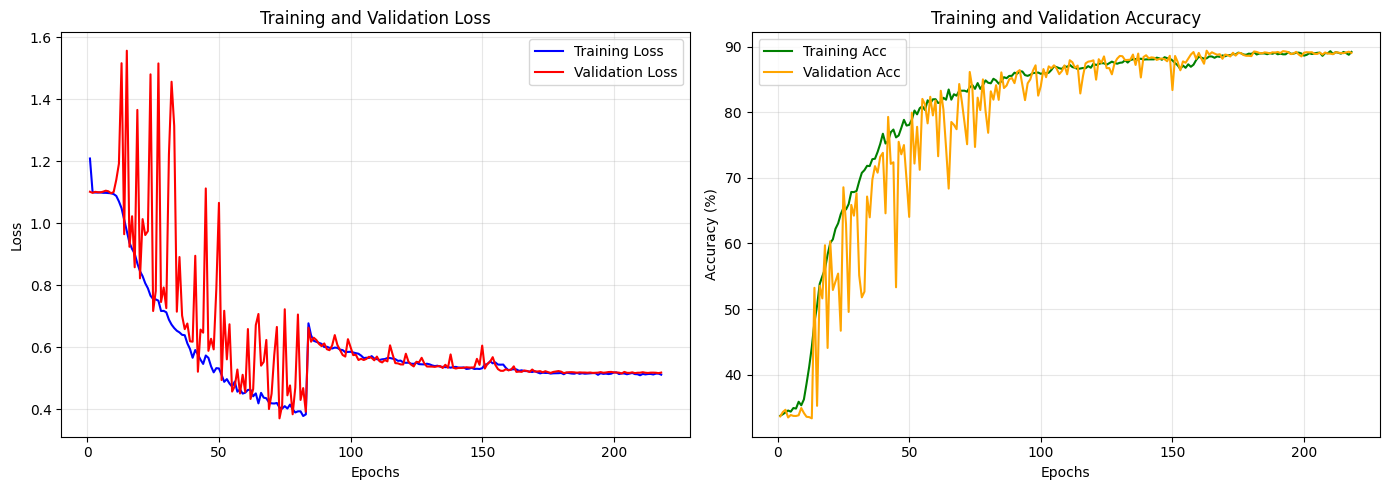

In [47]:
# Synchronize the lengths
min_len = min(len(train_losses), len(val_losses), len(train_accuracies), len(val_accuracies))

train_losses = train_losses[:min_len]
val_losses = val_losses[:min_len]
train_accuracies = train_accuracies[:min_len]
val_accuracies = val_accuracies[:min_len]

print(f"Arrays synchronized to length: {min_len}")

plot_history(train_losses, val_losses, train_accuracies, val_accuracies)

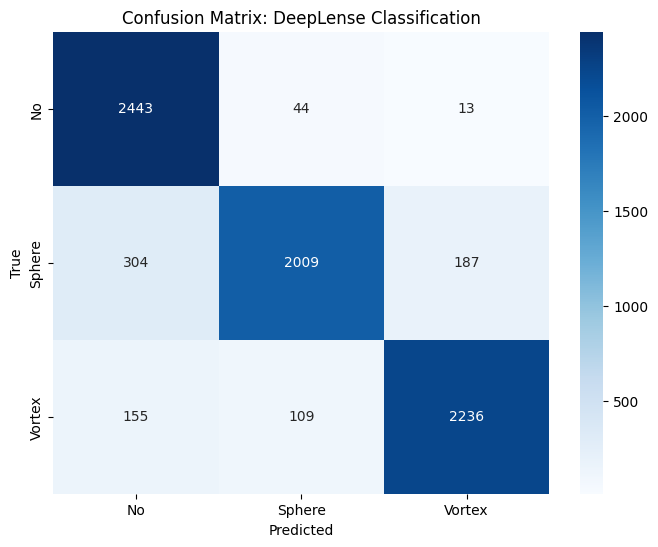

              precision    recall  f1-score   support

          No       0.84      0.98      0.90      2500
      Sphere       0.93      0.80      0.86      2500
      Vortex       0.92      0.89      0.91      2500

    accuracy                           0.89      7500
   macro avg       0.90      0.89      0.89      7500
weighted avg       0.90      0.89      0.89      7500



In [43]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

def generate_confusion_matrix(model, loader, device, classes):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Compute Matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    # Plotting
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix: DeepLense Classification')
    plt.show()
    
    # Print detailed stats
    print(classification_report(all_labels, all_preds, target_names=classes))

# Define your class names (e.g., ['no_sub', 'sub'])
# Replace this with the actual classes from your dataset
class_names = ['No', 'Sphere', 'Vortex'] 

# IMPORTANT: Load the 'best' model before running this!
model.load_state_dict(torch.load('best_deeplense_model_final.pth'))
generate_confusion_matrix(model, val_loader, device, class_names)

In [44]:
import torch
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import torch.nn.functional as F

def test_model(model, test_loader, device, classes):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    print("🚀 Starting Test Set Evaluation...")
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            
            # Get probabilities for AUC-ROC
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # Convert to numpy for sklearn
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    # 1. Print Standard Report
    print("\n--- Test Set Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=classes))
    
    # 2. Calculate AUC-ROC (One-vs-Rest for multiclass)
    auc_score = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    print(f"Total AUC-ROC Score: {auc_score:.4f}")
    
    return all_labels, all_probs

# Execution
# Ensure your class names match the 3 classes we found earlier
class_names = ['No Subhalo', 'Sphere', 'Vortex']

# Load the best weights one last time
model.load_state_dict(torch.load('best_deeplense_model_final.pth'))

test_labels, test_probs = test_model(model, test_loader, device, class_names)

🚀 Starting Test Set Evaluation...

--- Test Set Classification Report ---
              precision    recall  f1-score   support

  No Subhalo       0.84      0.98      0.90      1000
      Sphere       0.93      0.81      0.87      1000
      Vortex       0.92      0.88      0.90      1000

    accuracy                           0.89      3000
   macro avg       0.89      0.89      0.89      3000
weighted avg       0.89      0.89      0.89      3000

Total AUC-ROC Score: 0.9762


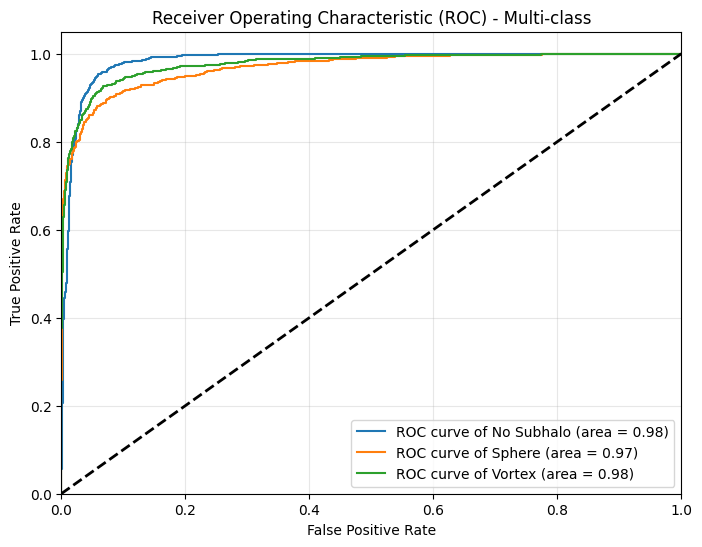

In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_multiclass_roc(y_test, y_score, n_classes, class_names):
    plt.figure(figsize=(8, 6))
    
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test == i, y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'ROC curve of {class_names[i]} (area = {roc_auc:0.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) - Multi-class')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

plot_multiclass_roc(test_labels, test_probs, 3, class_names)

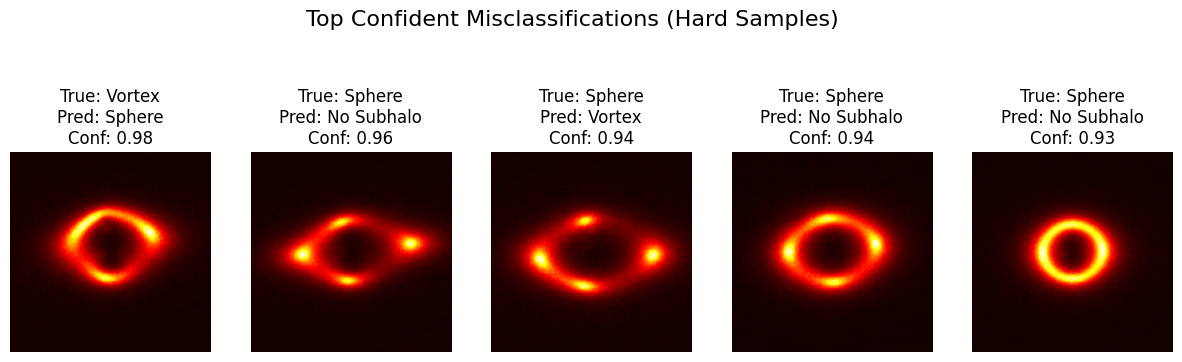

In [46]:
import matplotlib.pyplot as plt

def visualize_hardest_samples(model, loader, device, classes, num_samples=5):
    model.eval()
    errors = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            conf, preds = torch.max(probs, 1)
            
            # Find indices where prediction != label
            mask = preds != labels
            
            error_inputs = inputs[mask]
            error_labels = labels[mask]
            error_preds = preds[mask]
            error_conf = conf[mask]
            
            for i in range(len(error_inputs)):
                errors.append({
                    'image': error_inputs[i].cpu(),
                    'true': error_labels[i].item(),
                    'pred': error_preds[i].item(),
                    'conf': error_conf[i].item()
                })

    # Sort errors by confidence (highest confidence mistakes first)
    errors.sort(key=lambda x: x['conf'], reverse=True)

    # Plotting
    plt.figure(figsize=(15, 5))
    for i in range(min(num_samples, len(errors))):
        err = errors[i]
        plt.subplot(1, num_samples, i + 1)
        # Use squeeze() if your images are (1, H, W)
        plt.imshow(err['image'].squeeze(), cmap='hot')
        plt.title(f"True: {classes[err['true']]}\nPred: {classes[err['pred']]}\nConf: {err['conf']:.2f}")
        plt.axis('off')
    plt.suptitle("Top Confident Misclassifications (Hard Samples)", fontsize=16)
    plt.show()

# Run the visualizer
visualize_hardest_samples(model, test_loader, device, class_names)